CIFAR10を3層のCNNモデルで分類する

In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision


from Optimizers.SVRG import SVRG
from Optimizers.NFG_SVRG import NFG_SVRG
from Optimizers.ASAI_SVRG import ASAI_SVRG

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 10
SEED = 42
KEEP = True

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.62352943..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.827451..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6313726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9137255].
Clipping input data to the valid range 

tensor([[ 0.0086,  0.1501, -0.3415,  0.1259,  0.0144,  0.2912,  0.0420,  0.0116,
          0.1234, -0.1773]], grad_fn=<AddmmBackward0>)


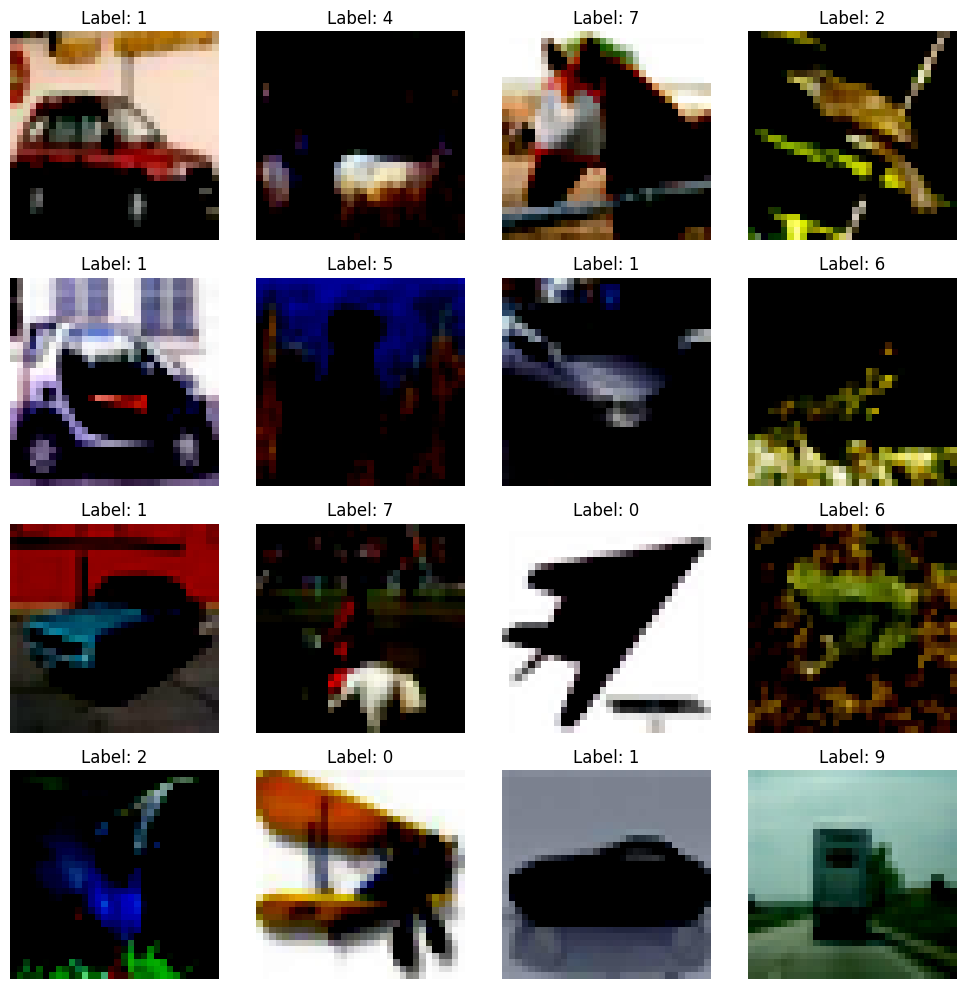

In [4]:
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

class CNN_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.GroupNorm(8, 32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.GroupNorm(8, 64) 
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.GroupNorm(8, 128) 
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 100)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(100, 10)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y    


print(CNN_Model()(torch.tensor(np.zeros(shape=(1,3,32,32)),dtype=torch.float32)))

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
ROOT_DIR = "outputs/CIFAR10_CNN3-1_01_NOTNORM"
TARGET_DIR = f"{ROOT_DIR}/{LEARNING_RATE}/{BATCH_SIZE}/{EPOCHS}/{SEED}"
os.makedirs(TARGET_DIR, exist_ok=True)

In [6]:
def epoch(loader, model, criterion, optimizer = None):
    '''
    loader:データローダー
    model:モデル
    criton:目的関数
    optimizer:手法
    '''
    if not optimizer == None:
        model.train()

    else:
        model.eval()

    total_loss, total_correct, total = 0, 0, 0
    pb = tqdm(loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        if not optimizer == None:

            if isinstance(optimizer, SVRG) or isinstance(optimizer, NFG_SVRG) or isinstance(optimizer, ASAI_SVRG):

                optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

        else:
            with torch.no_grad():
                Y = model(X)
                loss = criterion(Y, T)

        total_loss += loss.item() * T.size(0)

        pred = Y.argmax(dim=1)
        mini_correct = (pred == T).sum().item() / T.size(0)
        total_correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": mini_correct})

    epoch_loss = total_loss / total
    epoch_acc = total_correct / total

    return epoch_loss, epoch_acc

In [10]:
def loop(optimizer_class, save_dir):
    '''
    optimizer:手法
    save_dir:保存先
    '''
    set_seed(SEED)

    if not os.path.exists(f"{save_dir}/result.json"):
        train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
        test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)
        model = CNN_Model().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optimizer_class(model.parameters(), lr = LEARNING_RATE)

        train_loss_history = []
        test_loss_history = []
        train_acc_history = []
        test_acc_history = []
        norm_history = []
        x = []
        fg_count = 0

        for epochs in range(EPOCHS):
            print(f"epoch: {epochs + 1}")

            if epochs == 0:
                train_loss, train_acc = epoch(train_loader, model, criterion)

            else:

                if isinstance(optimizer, SVRG):
                    optimizer.calc_full_grads(model, train_loader, criterion)
                    fg_count += 1

                if isinstance(optimizer, NFG_SVRG) or isinstance(optimizer, ASAI_SVRG):
                    optimizer.init_epoch()
                    #diff_norm = optimizer.calc_diff_norm(model, train_loader, criterion)
                    #norm_history.append(diff_norm)
                
                train_loss, train_acc = epoch(train_loader, model, criterion, optimizer)
                fg_count += 1

                if isinstance(optimizer, SVRG) or isinstance(optimizer, NFG_SVRG) or isinstance(optimizer, ASAI_SVRG):
                    fg_count += 1

                if isinstance(optimizer, NFG_SVRG) or isinstance(optimizer, ASAI_SVRG):
                    optimizer.end_epoch()

            test_loss, test_acc = epoch(test_loader, model, criterion)

            x.append(fg_count)
            train_loss_history.append(train_loss)
            train_acc_history.append(train_acc)

            test_loss_history.append(test_loss)
            test_acc_history.append(test_acc)

            if (isinstance(optimizer, NFG_SVRG) or isinstance(optimizer, ASAI_SVRG)) and epochs != 0:
                #print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} |  Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f} | norm: {diff_norm}")
                print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} |  Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

            else:
                print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} |  Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

            if fg_count >= EPOCHS:
                break

        if KEEP:
            os.makedirs(save_dir, exist_ok=True)

            tmp = {
                "train_loss": train_loss_history,
                "train_acc": train_acc_history,
                "test_loss": test_loss_history,
                "test_acc": test_acc_history,
                "x": x,
            }
            if isinstance(optimizer, NFG_SVRG) or isinstance(optimizer, ASAI_SVRG):
                tmp["norm"] = norm_history
                
            with open(f"{save_dir}/result.json", "w") as f:
                json.dump(tmp, f, indent = 4)

In [ ]:
loop(optimizer_class = torch.optim.SGD, save_dir = f"{TARGET_DIR}/SGD")

In [ ]:
loop(optimizer_class = SVRG, save_dir = f"{TARGET_DIR}/SVRG")

In [11]:
loop(optimizer_class = NFG_SVRG, save_dir = f"{TARGET_DIR}/NFG_SVRG")

epoch: 1


100%|██████████| 157/157 [00:01<00:00, 120.73it/s, loss=2.25, acc=0.188] 


Train Loss: 2.3201, Acc: 0.0986 |  Test Loss: 2.3203, Acc: 0.0986
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 165.30it/s, loss=2.25, acc=0.188] 


Train Loss: 2.3201, Acc: 0.0986 |  Test Loss: 2.3203, Acc: 0.0986
epoch: 3


...

Train Loss: 2.2914, Acc: 0.1500 |  Test Loss: 2.2700, Acc: 0.2108
epoch: 4


100%|██████████| 157/157 [00:00<00:00, 159.15it/s, loss=2.2, acc=0.25]  


Train Loss: 2.2512, Acc: 0.2191 |  Test Loss: 2.2264, Acc: 0.2236
epoch: 5


 59%|█████▉    | 463/782 [00:05<00:03, 84.89it/s, loss=2.18, acc=0.156]


KeyboardInterrupt: 

In [ ]:
loop(optimizer_class = ASAI_SVRG, save_dir = f"{TARGET_DIR}/ASAI_SVRG")

100%|██████████| 157/157 [00:00<00:00, 172.98it/s, loss=1.17, acc=0.625] 


Train Loss: 1.0081, Acc: 0.6399 |  Test Loss: 1.0323, Acc: 0.6286
epoch: 121


100%|██████████| 157/157 [00:00<00:00, 168.88it/s, loss=1.18, acc=0.625] 


Train Loss: 1.0092, Acc: 0.6401 |  Test Loss: 1.0296, Acc: 0.6296
epoch: 122


 41%|████▏     | 324/782 [00:03<00:04, 92.13it/s, loss=1.1, acc=0.625]  